## Sequential Model 1

### Notebook Overview

This model addresses a **multiclass image classification** problem, where the goal is to predict the
artist of a painting from a set of 23 possible classes. It is built from scratch using the Keras
**Sequential API**, following the standard deep learning workflow:

1. **Loading the Data** — Images are loaded and resized to `(128, 128)`, yielding an input shape
of `(128, 128, 3)` (height × width × RGB channels). The dataset is split into training,
validation, and test sets.

2. **Preparing the Data** — All preprocessing is handled inside the model itself (see step 3),
meaning the pipeline travels with the model and is automatically applied at inference time.

3. **Building the Network** — The model is built with the Keras Sequential API and is composed
of three stages:
   - **Preprocessing**: `Rescaling(1./255)` for normalisation, and `RandomFlip`,
   `RandomRotation`, `RandomZoom` for data augmentation (training only).
   - **Feature Extraction**: 3 convolutional blocks, each pairing a `Conv2D` (3×3 kernels,
   ReLU activation, filter count doubling: 24 → 48 → 96) with a `MaxPooling2D(2×2)`.
   - **Classification Head**: `Flatten` followed by `Dense(23, activation='softmax')`,
   outputting a probability distribution over the 23 artist classes.

4. **Training the Model** — The model is compiled with `sparse_categorical_crossentropy` as the loss
function and trained with a validation split to monitor generalisation at every epoch.

   - **Plotting Loss & Accuracy** — Training and validation loss and accuracy are plotted across
epochs to visualise learning progress and detect overfitting.

   - **Callbacks** — `ModelCheckpoint` saves the best model weights during training;
`EarlyStopping` halts training when validation loss stops improving, preventing overfitting
and unnecessary computation.

5. **Generating Predictions on Unseen Data** — The saved best model is loaded and used to
generate predictions on new images, returning the predicted artist class for each input.

6. **Image Augmentation Tuning**


### 1. Loading the Data

We are going to use image_dataset_from_directory that reads directly from the folder structure. To start we aren't using weights just yet

In [39]:
# imports and constants
import os 
import keras
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Model building imports
from keras import Sequential, Input
from keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, RandomBrightness, RandomContrast, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandAugment
from keras import callbacks, optimizers, losses


import tensorflow as tf
from tensorflow import keras
from keras import layers

# ver tamanho das imagens
split_dir = os.path.join("..", "dataset_split")
image_size = (128, 128)
batch_size = 32 # for lower GPU/CPU usage (but it as a lower training speed)
input_shape = (128, 128, 3)
seed = 42
epochs = 32

In [15]:
# check the percentage of every painter in the train and test dataset to see if the slipt was done correctly

def class_distribution(split_dirs: dict):
    """Shows the count and percentage of each artist per split.
    
    Args:
        split_dirs (dict): e.g. {"train": "data_splits/train", "test": "data_splits/test"}
    """
    data = {}
    for split_name, split_path in split_dirs.items():
        counts = {
            artist: len(os.listdir(os.path.join(split_path, artist)))
            for artist in sorted(os.listdir(split_path))
        }
        total = sum(counts.values())
        data[f"{split_name} (n)"] = counts
        data[f"{split_name} (%)"] = {k: f"{v / total * 100:.1f}%" for k, v in counts.items()}

    df = pd.DataFrame(data)
    df.index.name = "Artist"
    return df

class_distribution({
    "train": "../dataset_split/train",
    "validation":"../dataset_split/val",
    "test": "../dataset_split/test"
})


,train (n),train (%),validation (n),validation (%),test (n),test (%)
Artist,,,,,,
Albrecht_Durer,406,4.3%,87,4.3%,87,4.3%
Boris_Kustodiev,311,3.3%,67,3.3%,66,3.3%
Camille_Pissarro,435,4.7%,93,4.6%,93,4.6%
Childe_Hassam,269,2.9%,58,2.9%,58,2.9%
Claude_Monet,654,7.0%,140,7.0%,140,7.0%
Edgar_Degas,300,3.2%,64,3.2%,64,3.2%
Eugene_Boudin,272,2.9%,58,2.9%,59,2.9%
Gustave_Dore,370,4.0%,79,3.9%,79,3.9%
Ilya_Repin,265,2.8%,57,2.8%,56,2.8%


/var/folders/f0/h1r1t1l15cz_0gjkxj_2n_qr0000gn/T/ipykernel_5927/153232049.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right")


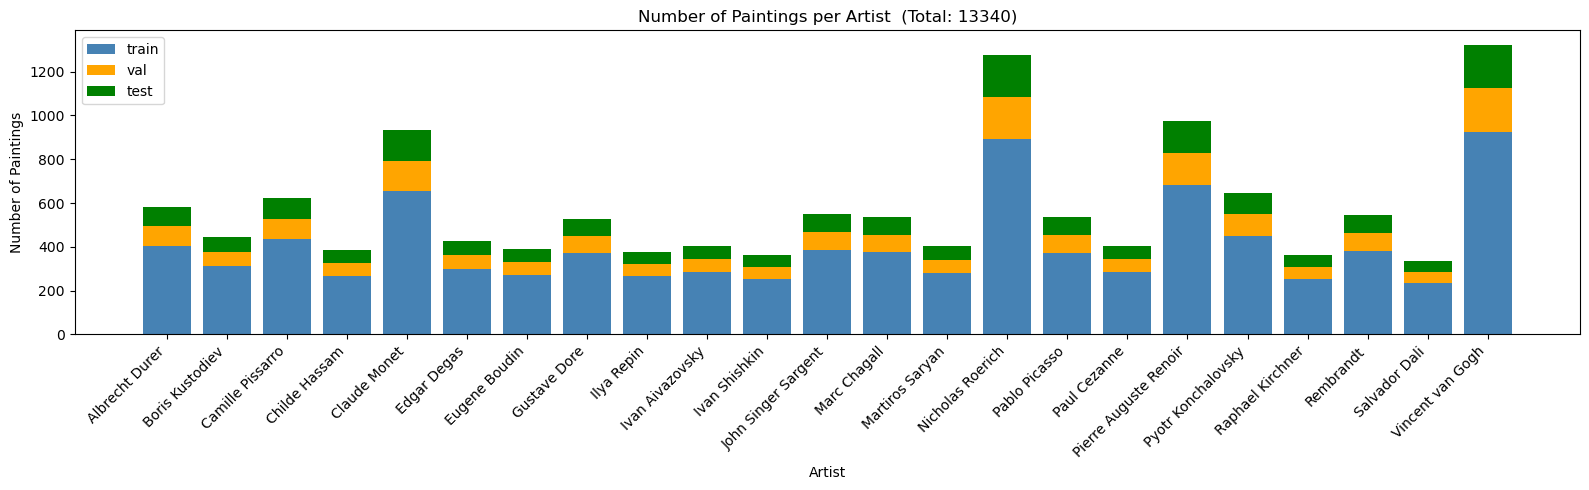

In [16]:
# bar plots to see the number os paintings by artist in the three datasets
splits_to_plot = ["train", "val", "test"]
artists = sorted(os.listdir(os.path.join(split_dir, "train")))
labels = [a.replace("_", " ") for a in artists]
colors = ["steelblue", "orange", "green"]

fig, ax = plt.subplots(figsize=(16, 5))
bottoms = np.zeros(len(artists))
for split_name, color in zip(splits_to_plot, colors):
    counts = np.array([len(os.listdir(os.path.join(split_dir, split_name, artist))) for artist in artists])
    ax.bar(labels, counts, bottom=bottoms, label=split_name, color=color)
    bottoms += counts

total = int(bottoms.sum())
ax.set_xlabel("Artist")
ax.set_ylabel("Number of Paintings")
ax.set_title(f"Number of Paintings per Artist  (Total: {total})")
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

#### Dataset Distribution

The bar chart above shows the number of paintings per artist across the three splits (train,
validation and test).

The dataset contains **13,340 paintings** across **23 artists**, split into training (9,338),
validation (2,001) and test (2,001) sets. The split was performed in a **stratified** manner,
meaning each artist's proportion is preserved consistently across all three sets — for example,
Vincent van Gogh represents 9.9% of both the training and test sets. This ensures the model is
evaluated under the same class distribution it was trained on.

However, the dataset is notably **imbalanced**. Vincent van Gogh (925 train, 9.9%) and
Nicholas Roerich (892 train, 9.6%) have nearly four times more paintings than the smallest
classes such as Salvador Dalí (235 train, 2.5%), Raphael Kirchner (253 train, 2.7%) and Ivan
Shishkin (255 train, 2.7%). This imbalance means the model is exposed to some artists far more
frequently during training, which can bias it towards predicting the larger classes — directly
motivating the use of macro F1-score as the primary evaluation metric rather than accuracy.

In [17]:
# loading datasets (same as Pedro's)

train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "train"),
    image_size = image_size,
    batch_size = batch_size,
    label_mode = "int", 
    # The labels are foing to be integers (0, 1, 2, ....) 
    # -> we are going to use the sparse_categorical_crossentropy loss in the label enconding part
    shuffle = True, # only on the train dataset
    seed = seed # reproducible
)

val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "val"),
    image_size = image_size,
    batch_size = batch_size,
    label_mode = "int", 
    shuffle = False 
)

test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "test"),
    image_size = image_size,
    batch_size = batch_size,
    label_mode = "int", 
    shuffle = False
)

# check to see if the loading is correct
num_classes = len(train_ds.class_names)
class_names = train_ds.class_names
print(f"Classes ({num_classes}): {class_names}")



Found 9338 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


## 2. Data Preparation and 3. Building the Model

The model is built with the Keras **Sequential API** — a linear stack of layers where
transformations are applied in order from top to bottom. This is the simplest and most readable
way to build a deep learning model in Keras, and is well-suited for a straightforward image
classification pipeline.

---

### Preprocessing

Preprocessing is embedded directly as the first layers of the model, meaning the logic travels
with the model and is automatically applied to any new image fed for prediction.

- **`Rescaling(1./255)`** — maps raw pixel values from `[0, 255]` to `[0.0, 1.0]`, putting
the input on the same scale as the network's weights and allowing gradient descent to work
effectively.
- **`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomTranslation`, `RandomBrightness`,
`RandomContrast`** — data augmentation layers applied *only during training*, automatically
inactive at inference time. They artificially increase training diversity, forcing the model to
learn features robust to orientation, scale, position and colour changes rather than memorising
specific pixel arrangements. This directly combats overfitting when training from scratch.

---

### Feature Extraction — 3 Convolutional Blocks

Each block pairs a `Conv2D` layer with a `MaxPooling2D` layer:

- **`Conv2D`** — slides a 3×3 kernel across the image to detect local spatial patterns. Early
blocks detect low-level features (edges, colours); deeper blocks detect more abstract structures
(textures, brushstroke patterns). The filter count doubles across blocks (24 → 48 → 96), giving
the network progressively more representational capacity. **ReLU activation** introduces the
non-linearity that allows the network to learn complex, hierarchical representations.
- **`MaxPooling2D(2×2)`** — halves spatial dimensions after each block, reducing computation
and introducing spatial invariance: small shifts in where a feature appears produce similar
outputs.

---

### Classification Head

- **`Flatten`** — reshapes the final 3D feature volume into a 1D vector. No weights involved,
pure restructuring.
- **`Dense(256, activation='relu')`** — an intermediate fully connected layer that allows the
network to learn non-linear combinations of the extracted features before the final
classification step, avoiding an abrupt jump from the high-dimensional flattened vector to the
23 output classes.
- **`Dropout(0.2)`** — randomly disables 20% of neurons during each training step, preventing
the network from relying too heavily on any single neuron and encouraging more robust,
distributed representations. Inactive at inference time.
- **`Dense(num_classes, activation='softmax')`** — outputs a probability distribution over the
23 artist classes. The predicted class is the index with the highest probability.

In [18]:
sequencial_model_1 = Sequential(
    layers = [
        Input(shape = input_shape),
        Rescaling(scale= 1/255.0), # normalization layer
        # agumentation layers
        RandomFlip(mode="horizontal", seed=seed),
        RandomRotation(
            factor=0.2,
            fill_mode="reflect",
            interpolation="bilinear",
            seed=seed,
        ),
        RandomZoom(
            height_factor=0.1,
            width_factor=0.1,
            fill_mode="reflect",
            interpolation="bilinear",
            seed=seed
        ),
        RandomTranslation(height_factor=0.1, width_factor=0.1, seed=seed),
        RandomBrightness(factor=0.3, value_range=(0.0, 1.0)),
        RandomContrast(factor=0.3),
        
        # Convolution and MaxPooling Layers
        # we need to double the filters so the network can detect increasingly complex and abstract features at each level
        Conv2D(filters=3 * 8,  kernel_size=(3, 3), activation="relu"), # detect simple and local features (like edges)
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(filters=3 * 16, kernel_size=(3, 3), activation="relu"), # combine those edges into textures and shapes
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(filters=3 * 32, kernel_size=(3, 3), activation="relu"), # combine those into high-level concepts (ex: painting style)
        MaxPooling2D(pool_size=(2, 2)),
        # Flatten and Dense layer
        Flatten(),
        Dense(256, activation="relu"), # so the jump in units isn't that high
        Dropout(0.2), # randomly disables 20% of neurons during training (Why is this better?)
        Dense(num_classes, activation="softmax")   
    ],
    name = "sequencial_model_1"
)

sequencial_model_1.summary()

Model: "sequencial_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 128, 128, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 128, 128, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,817,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,875,719 (18.60 MB)

 Trainable params: 4,875,719 (18.60 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Training the model

In [19]:
# Save the best model
callbacks_list = [
		keras.callbacks.EarlyStopping(
		monitor="val_accuracy",
		patience=5, # interrupts the training when the models stops to get better after 5 epoch
	),
	 keras.callbacks.ModelCheckpoint(
	 filepath="../saved_models/sequential_model_1_best.keras",
	 monitor="val_loss",
	 save_best_only=True
	)
]

sequencial_model_1.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

trained_model = sequencial_model_1.fit(
    train_ds, validation_data=val_ds,
    epochs=epochs, callbacks=callbacks_list,
)

Epoch 1/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 35s 117ms/step - accuracy: 0.1656 - loss: 2.8561 - val_accuracy: 0.2059 - val_loss: 2.6634
Epoch 2/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 35s 118ms/step - accuracy: 0.2211 - loss: 2.6405 - val_accuracy: 0.2394 - val_loss: 2.8188
Epoch 3/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 37s 127ms/step - accuracy: 0.2567 - loss: 2.5023 - val_accuracy: 0.2704 - val_loss: 2.4835
Epoch 4/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 39s 133ms/step - accuracy: 0.2915 - loss: 2.3878 - val_accuracy: 0.2999 - val_loss: 2.3659
Epoch 5/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 39s 133ms/step - accuracy: 0.3028 - loss: 2.3149 - val_accuracy: 0.3223 - val_loss: 2.3183
Epoch 6/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 40s 135ms/step - accuracy: 0.3253 - loss: 2.2501 - val_accuracy: 0.3248 - val_loss: 2.3443
Epoch 7/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 40s 137ms/step - accuracy: 0.3370 - loss: 2.2177 - val_accuracy: 0.3368 - val_loss: 2.3482
Epoch 8/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 40s 136ms/step - accuracy: 0.3536 - loss: 2

In [20]:
%run -i ../utils/loss_and_accuracy_plots.py

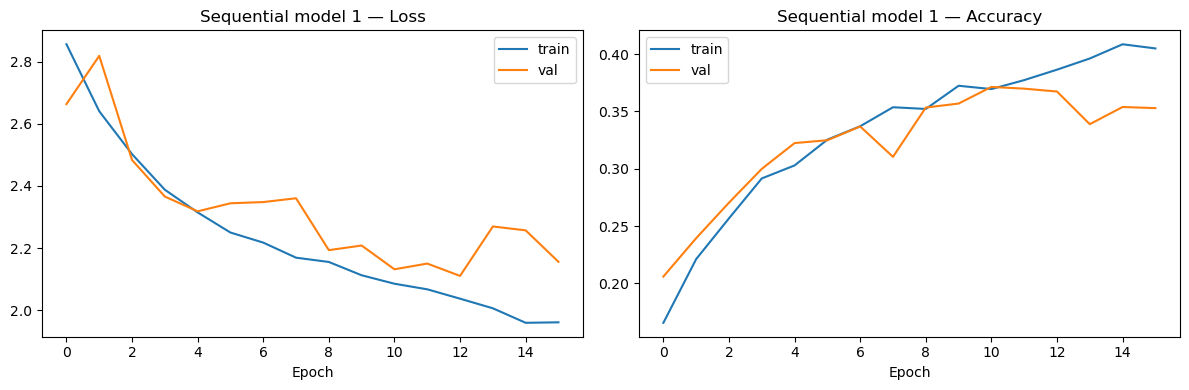

In [21]:
plot_history(trained_model, "Sequential model 1")

### 5. Generating prediction os unseen data

In [22]:
best_sequencial_model_1 = keras.models.load_model("../saved_models/sequential_model_1_best.keras")

In [23]:
%run -i ../utils/evaluation_report.py

2026-04-16 21:31:27.669351: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 

--------- Classification report ---------
Top-1: 0.3433  Top-3: 0.6007  Top-5: 0.7226

                       precision    recall  f1-score   support

       Albrecht_Durer       0.43      0.15      0.22        87
      Boris_Kustodiev       0.29      0.08      0.12        66
     Camille_Pissarro       0.34      0.40      0.36        93
        Childe_Hassam       0.16      0.09      0.11        58
         Claude_Monet       0.62      0.32      0.42       140
          Edgar_Degas       0.22      0.06      0.10        64
        Eugene_Boudin       0.52      0.39      0.45        59
         Gustave_Dore       0.56      0.73      0.64        79
           Ilya_Repin       0.33      0.14      0.20        56
      Ivan_Aivazovsky       0.87      0.56      0.68        61
        Ivan_Shishkin       0.33      0.16      0.22        55
  John_Singer_Sargent       0.45      0.30      0.36        82
         Marc_Chagall       0.15      0.36      0.21        81
      Martiros_Saryan       0.

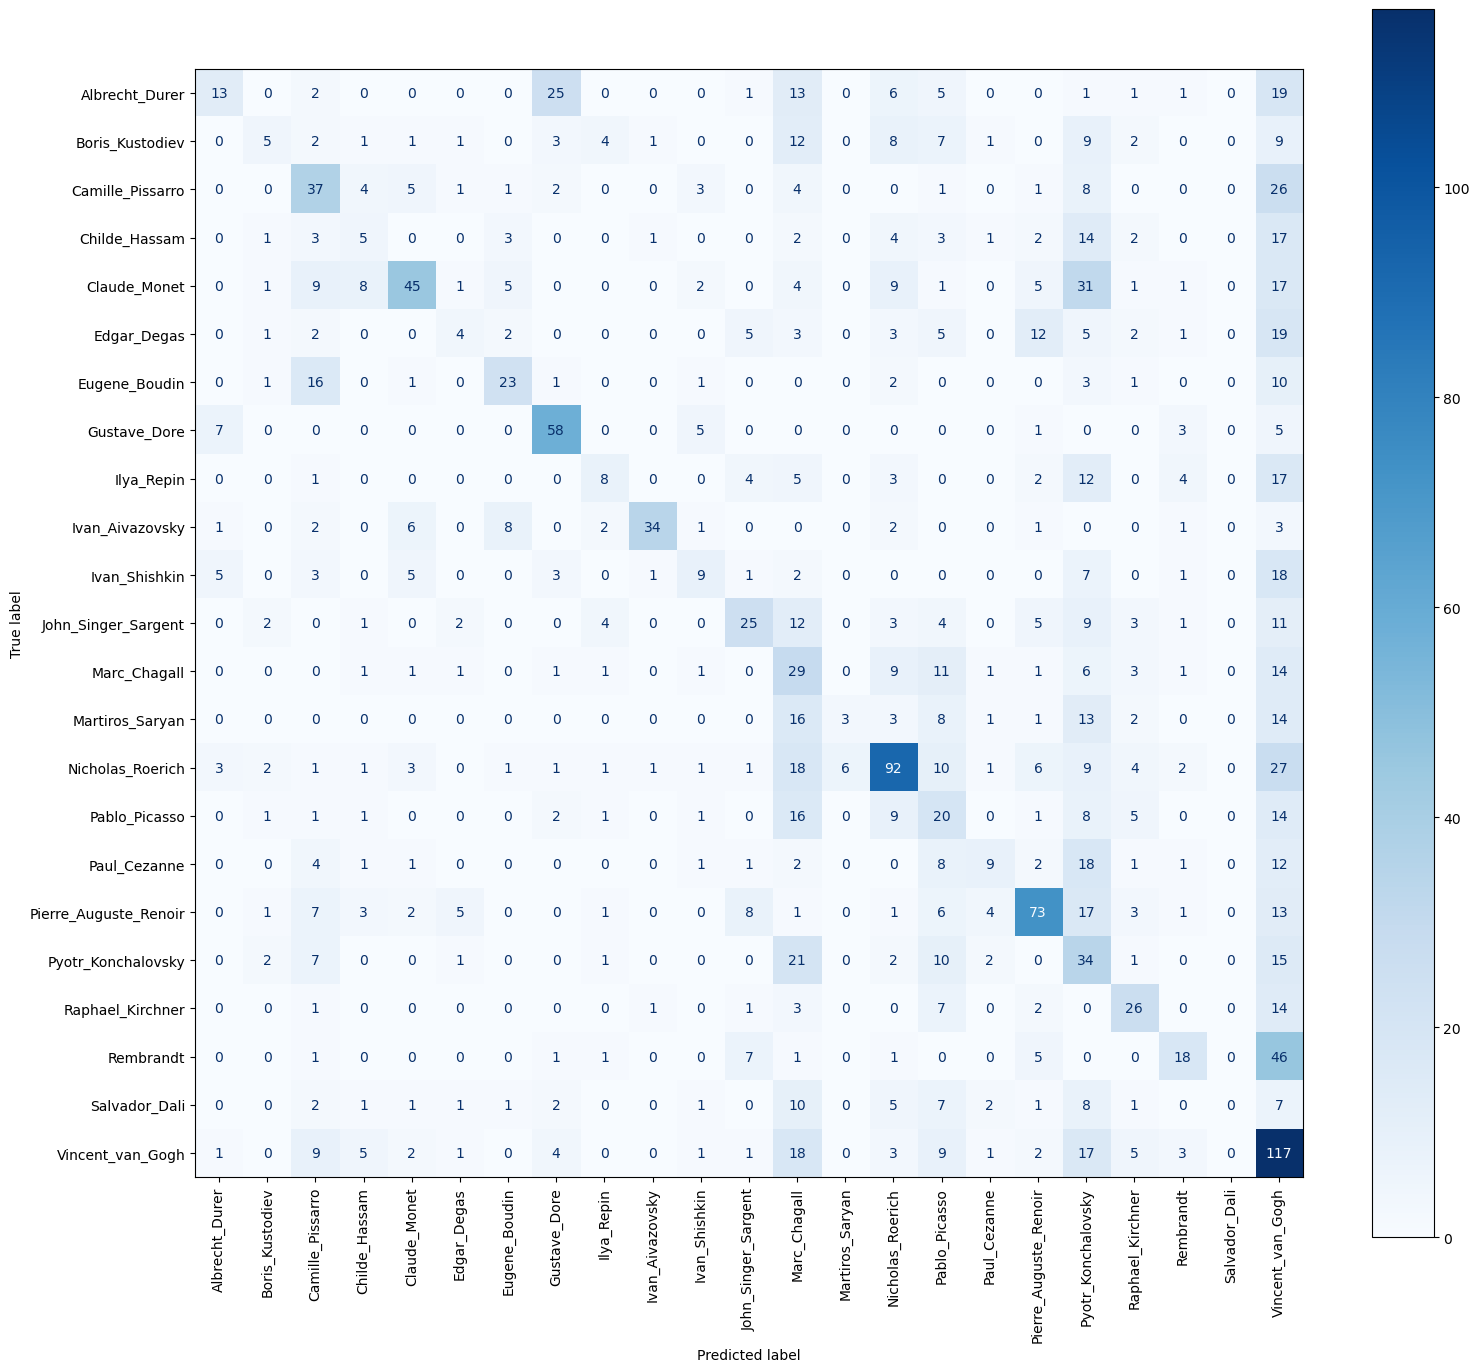

--------- Top 10 misclassifications ---------

                   True Artist  →  Predicted As                    Count
------------------------------------------------------------------------------------------
                     Rembrandt  →  Vincent_van_Gogh                46
                  Claude_Monet  →  Pyotr_Konchalovsky              31
              Nicholas_Roerich  →  Vincent_van_Gogh                27
              Camille_Pissarro  →  Vincent_van_Gogh                26
                Albrecht_Durer  →  Gustave_Dore                    25
            Pyotr_Konchalovsky  →  Marc_Chagall                    21
                Albrecht_Durer  →  Vincent_van_Gogh                19
                   Edgar_Degas  →  Vincent_van_Gogh                19
                 Ivan_Shishkin  →  Vincent_van_Gogh                18
              Nicholas_Roerich  →  Marc_Chagall                    18


In [24]:
evaluate_model(best_sequencial_model_1, test_ds, class_names)

#### Classification report

As previously mentioned, our dataset is imbalanced across the 23 artist classes — for example,
Nicholas Roerich has 191 paintings in the test set while Childe Hassam has only 58. In this
context, **accuracy is a misleading metric**: a model that performs well on large classes but
poorly on smaller ones can still report a deceptively high overall accuracy.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

This is confirmed by our results: the model achieves an overall **accuracy of 0.34**, but the
per-class performance varies drastically — Ivan Aivazovsky reaches an F1-score of 0.68 while
Martiros Saryan sits at just 0.09. Accuracy alone would mask this imbalance entirely.

**For this reason, macro F1-score was adopted as the primary evaluation metric.** The macro
average computes F1 independently for each class and averages them equally, meaning every artist
— regardless of how many paintings they contribute — has the same weight in the final score.
This ensures the model is not rewarded for ignoring underrepresented classes.

$$
\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}
$$

Overall, this model achieved a **macro F1-score of 0.30**.

---

#### Confusion Matrix & Misclassification Analysis

The confusion matrix reveals how predictions are distributed across the 23 classes, making it
possible to identify not just *how often* the model is wrong, but *which artists it confuses
with which*. Rather than a single aggregate number, it exposes the structural weaknesses of the
model at a class level.

The top 10 most frequent misclassifications are:

| True Artist | Predicted As | Count |
|---|---|---|
| Rembrandt | Vincent van Gogh | 46 |
| Claude Monet | Pyotr Konchalovsky | 31 |
| Nicholas Roerich | Vincent van Gogh | 27 |
| Camille Pissarro | Vincent van Gogh | 26 |
| Albrecht Durer | Gustave Doré | 25 |
| Pyotr Konchalovsky | Marc Chagall | 21 |
| Albrecht Durer | Vincent van Gogh | 19 |
| Edgar Degas | Vincent van Gogh | 19 |
| Ivan Shishkin | Vincent van Gogh | 18 |
| Nicholas Roerich | Marc Chagall | 18 |

**Vincent van Gogh** emerges as the dominant catch-all prediction, absorbing misclassifications
from six different artists — Rembrandt, Nicholas Roerich, Camille Pissarro, Albrecht Dürer,
Edgar Degas and Ivan Shishkin. With 199 test samples, he is the largest class in the dataset,
making him a statistically safe default guess for the model when uncertain. **Pyotr
Konchalovsky** also continues to attract misclassifications, notably from Claude Monet. These
patterns suggest the model has not yet learned sufficiently discriminative per-artist features,
and that class imbalance remains a significant driver of the error structure.

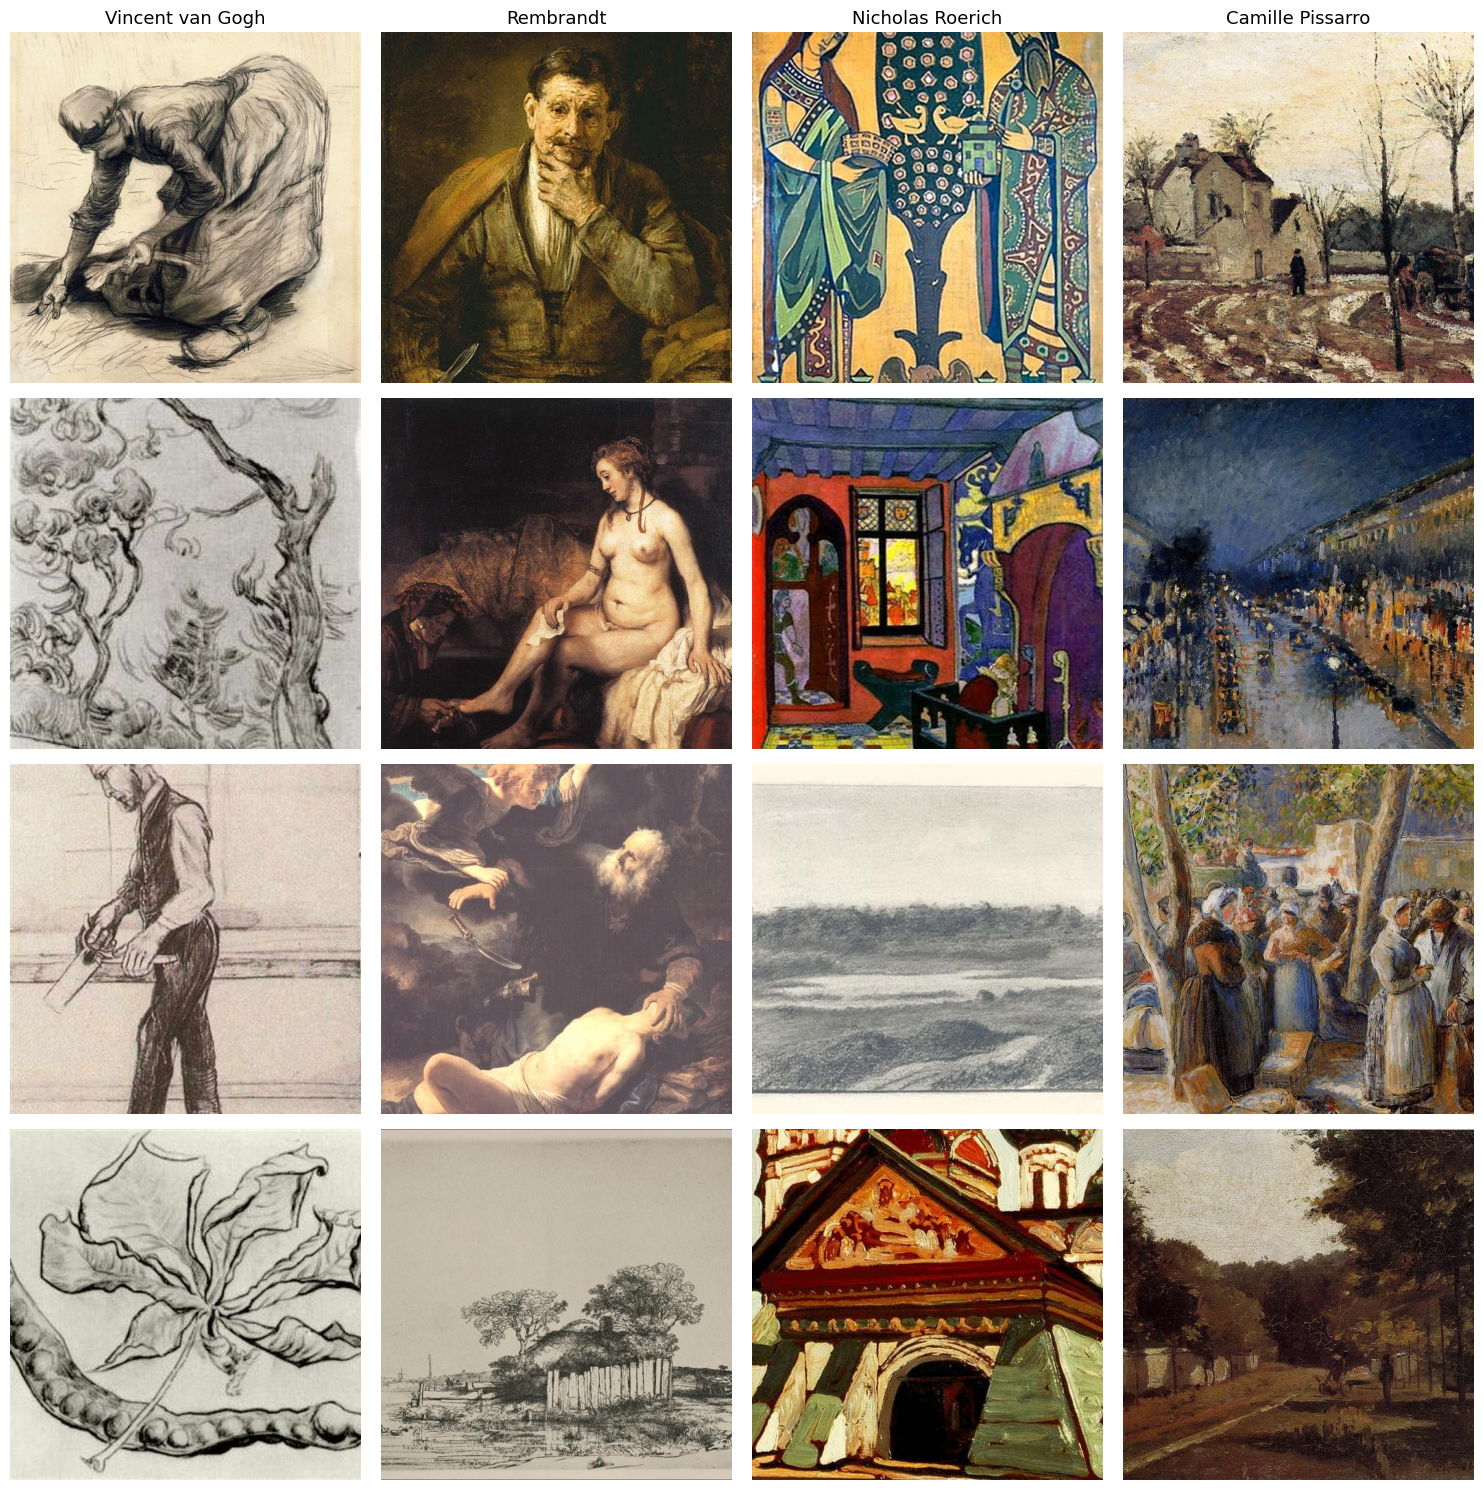

In [29]:
# Comparison between Vincent van Gogh, Rembrandt, Nicholas Roerich, Camille Pissarro styles
artists = ["Vincent_van_Gogh", "Rembrandt", "Nicholas_Roerich", "Camille_Pissarro"]
train_splited_dir = "../dataset_split/train"

n_cols = 4
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))

for col, artist in enumerate(artists):
    artist_dir = os.path.join(train_splited_dir, artist)
    images = os.listdir(artist_dir)[:n_rows]  # take the first 4 images
    for row, img_name in enumerate(images):
        img_path = os.path.join(artist_dir, img_name)
        img = keras.utils.load_img(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(artist.replace("_", " "), fontsize=13)

plt.tight_layout()
plt.show()

These patterns suggest that the model has not yet learned sufficiently discriminative
per-artist features, and are further explained by the visual characteristics of the dataset
itself. Artists like Nicholas Roerich display significant **intra-class variability**, making
it difficult for a shallow CNN to learn a consistent visual signature. Similarly, Vincent van
Gogh's dataset contains pencil sketches that are visually indistinguishable from Rembrandt's
tonal drawing style, which directly explains their frequent mutual confusion.

Additionally, Impressionist artists such as Camille Pissarro share compositional and colour palette similarities with Monet and Renoir, further compounding the classification difficulty.

**These observations point to directions for improvement such as deeper architectures with greater representational capacity, stronger regularisation, or class-weighted training to penalise errors on minority classes more heavily.** 

### 6. Fine Tuning — RandAugment Experiment

To investigate whether stronger and more diverse augmentation could improve the model's
generalisation, a second training experiment was conducted using `RandAugment`. Rather than
manually stacking individual augmentation layers, `RandAugment` randomly selects and applies a
combination of transformations per image, providing greater diversity during training.

Critically, this experiment required training a **brand new model** with the same architecture
(`sequencial_model_1_randaug`), compiled and fitted from scratch on the augmented dataset
`train_ds_aug`. Reusing the previously trained model and calling `model.fit()` again would not
reset the weights — the model would simply continue training from where it left off, carrying
over everything it had already learned from the original data, making the comparison invalid.

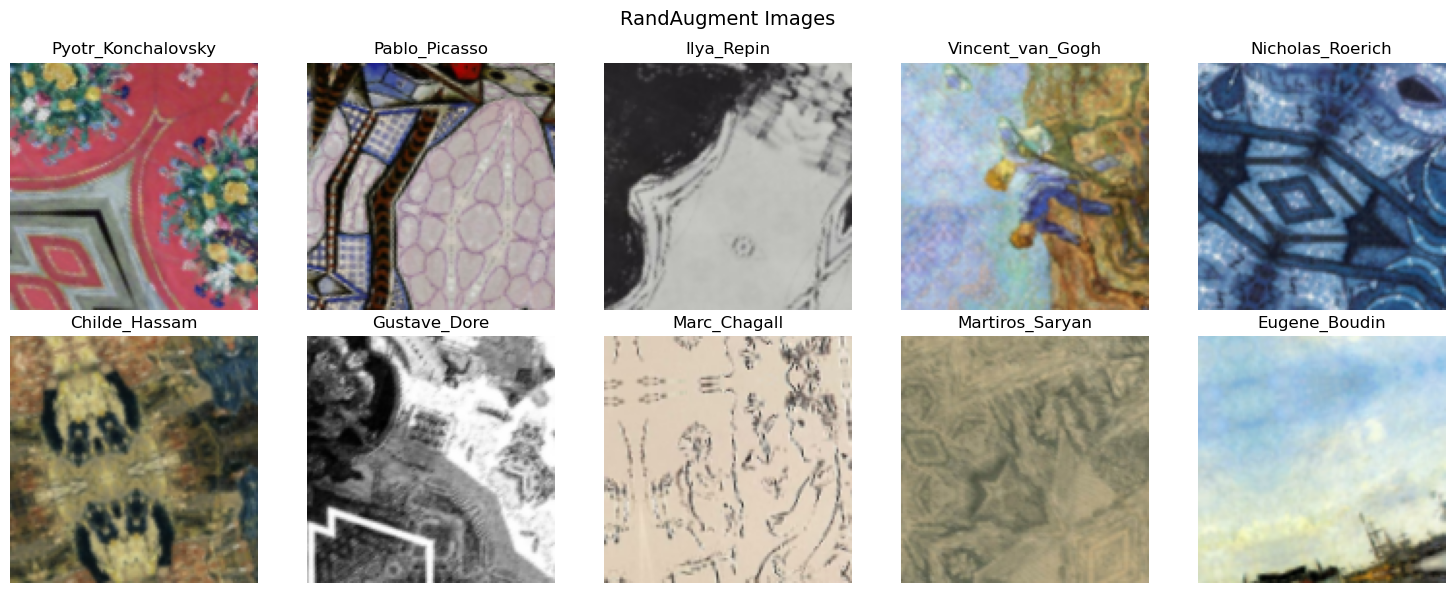

In [41]:
# Random Augmentation:

# Applying RandAugment to the training dataset to see if it leads to a better F1-Score.
# RandAugment randomly selects and applies a combination of transformations per image,
# providing more diversity than manually stacking individual layers.
augmentation_layer = keras.Sequential([
    layers.RandAugment(
        value_range=(0, 255), # before rescaling
        num_ops=3,
        factor=0.5,
        interpolation="bilinear"
    )
], name="augmentation_layer")

# Apply to training dataset only
train_ds_aug = train_ds.map(
    lambda image, label: (augmentation_layer(image, training=True), label),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Plot augmented images
sample_images, sample_labels = next(iter(train_ds_aug))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("RandAugment Images", fontsize=14)
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].numpy().astype("uint8"))
    ax.set_title(class_names[sample_labels[i].numpy()])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [42]:
# New model with the same architetcture 

sequencial_model_1_randaug = Sequential(
    layers=[
        Input(shape=input_shape),
        Rescaling(scale=1/255.0),
        RandomFlip(mode="horizontal", seed=seed),
        RandomRotation(factor=0.2, fill_mode="reflect", interpolation="bilinear", seed=seed),
        RandomZoom(height_factor=0.1, width_factor=0.1, fill_mode="reflect", interpolation="bilinear", seed=seed),
        RandomTranslation(height_factor=0.1, width_factor=0.1, seed=seed),
        RandomBrightness(factor=0.3, value_range=(0.0, 1.0)),
        RandomContrast(factor=0.3),
        Conv2D(filters=3 * 8,  kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(filters=3 * 16, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(filters=3 * 32, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(256, activation="relu"),
        Dropout(0.2),
        Dense(num_classes, activation="softmax")
    ],
    name="sequencial_model_1_randaug"
)

callbacks_list_randaug_experiment = [
		keras.callbacks.EarlyStopping(
		monitor="val_accuracy",
		patience=5, # interrupts the training when the models stops to get better after 5 epoch
	),
	 keras.callbacks.ModelCheckpoint(
	 filepath="../saved_models/sequential_model_1_best_randaug_experiment.keras",
	 monitor="val_loss",
	 save_best_only=True
	)
]

sequencial_model_1_randaug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

sequencial_model_1_randaug.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks_list_randaug_experiment
)

Epoch 1/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 69s 230ms/step - accuracy: 0.1135 - loss: 3.0342 - val_accuracy: 0.1399 - val_loss: 2.8874
Epoch 2/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 73s 247ms/step - accuracy: 0.1248 - loss: 2.9488 - val_accuracy: 0.1264 - val_loss: 2.8443
Epoch 3/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 76s 255ms/step - accuracy: 0.1379 - loss: 2.9010 - val_accuracy: 0.2014 - val_loss: 2.7249
Epoch 4/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 83s 281ms/step - accuracy: 0.1478 - loss: 2.8713 - val_accuracy: 0.2094 - val_loss: 2.6983
Epoch 5/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 89s 299ms/step - accuracy: 0.1614 - loss: 2.8203 - val_accuracy: 0.2269 - val_loss: 2.6160
Epoch 6/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 89s 298ms/step - accuracy: 0.1768 - loss: 2.7789 - val_accuracy: 0.2614 - val_loss: 2.5127
Epoch 7/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 90s 303ms/step - accuracy: 0.1844 - loss: 2.7590 - val_accuracy: 0.2584 - val_loss: 2.4987
Epoch 8/32
292/292 ━━━━━━━━━━━━━━━━━━━━ 91s 306ms/step - accuracy: 0.1952 - loss: 2

--------- Classification report ---------
Top-1: 0.3398  Top-3: 0.5702  Top-5: 0.6922

                       precision    recall  f1-score   support

       Albrecht_Durer       0.43      0.33      0.37        87
      Boris_Kustodiev       0.00      0.00      0.00        66
     Camille_Pissarro       0.34      0.49      0.40        93
        Childe_Hassam       0.00      0.00      0.00        58
         Claude_Monet       0.30      0.54      0.39       140
          Edgar_Degas       1.00      0.02      0.03        64
        Eugene_Boudin       0.48      0.20      0.29        59
         Gustave_Dore       0.50      0.84      0.63        79
           Ilya_Repin       0.29      0.04      0.06        56
      Ivan_Aivazovsky       0.69      0.30      0.41        61
        Ivan_Shishkin       0.25      0.02      0.03        55
  John_Singer_Sargent       0.37      0.28      0.32        82
         Marc_Chagall       0.15      0.02      0.04        81
      Martiros_Saryan       0.

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

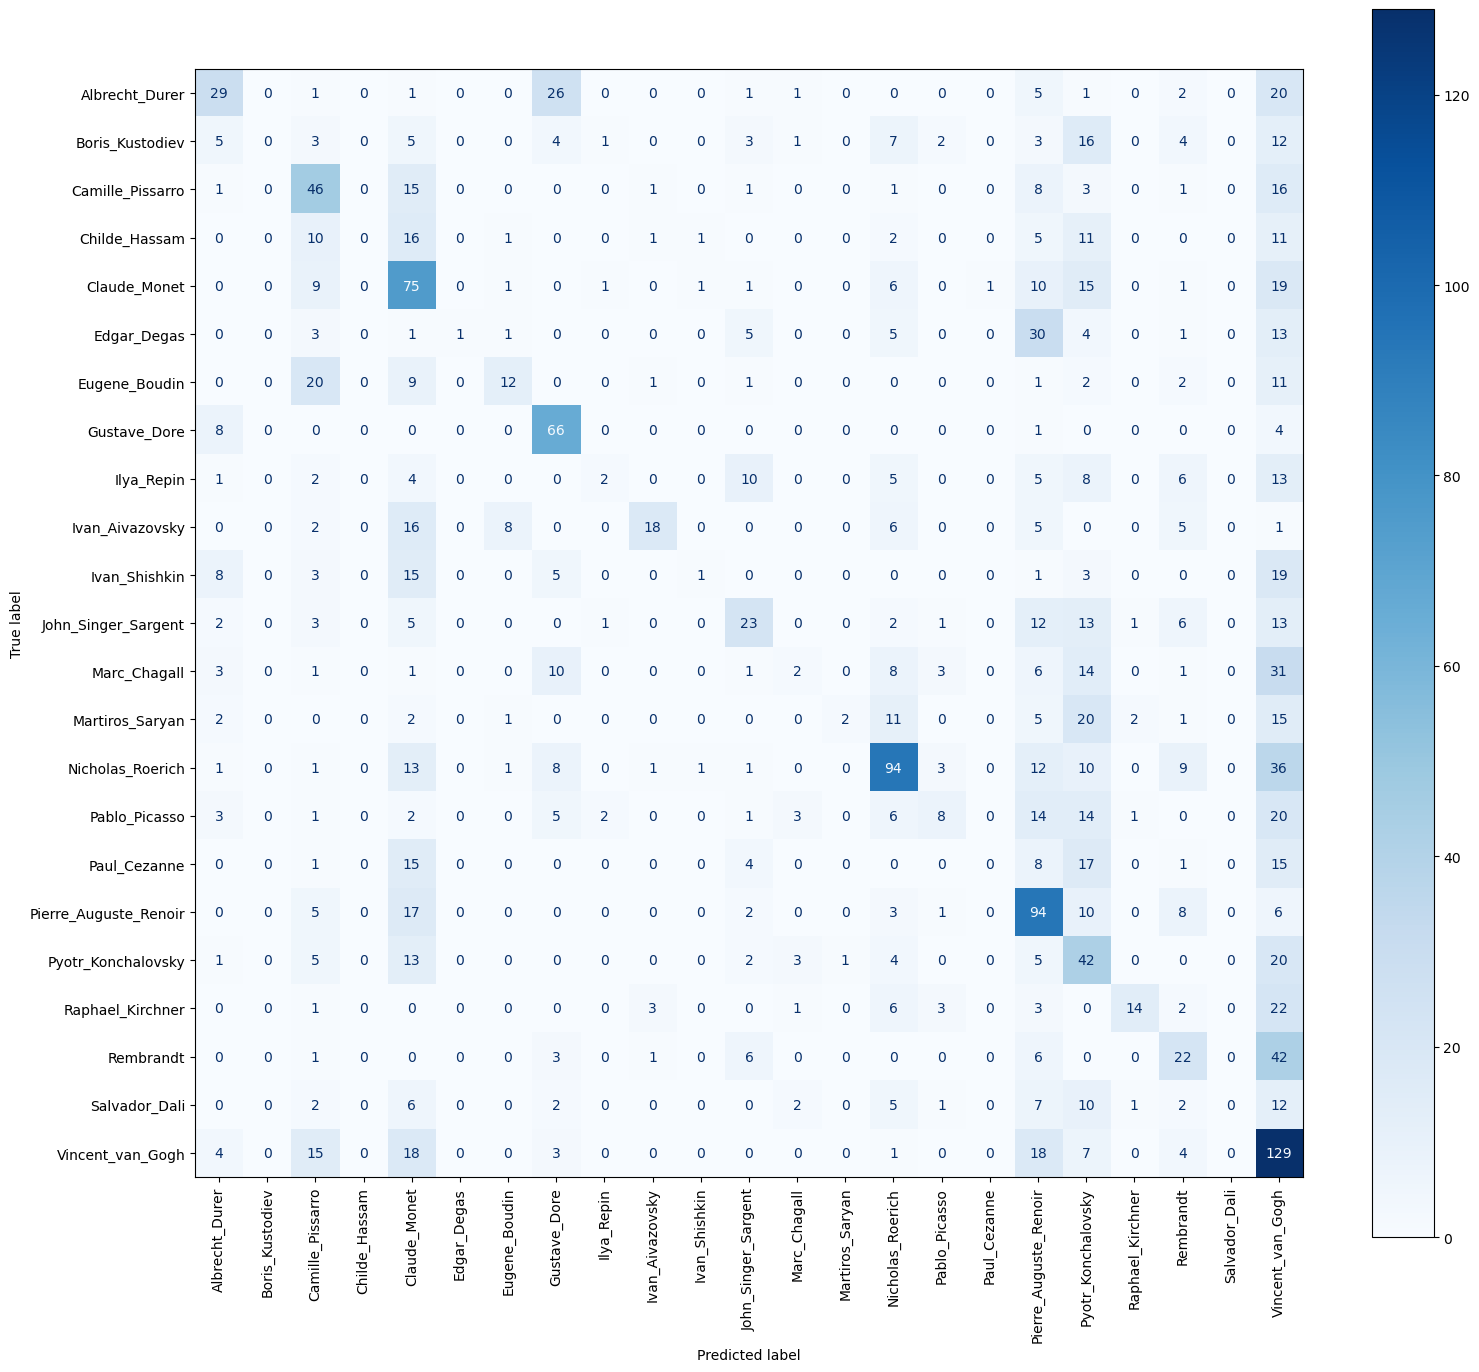

--------- Top 10 misclassifications ---------

                   True Artist  →  Predicted As                    Count
------------------------------------------------------------------------------------------
                     Rembrandt  →  Vincent_van_Gogh                42
              Nicholas_Roerich  →  Vincent_van_Gogh                36
                  Marc_Chagall  →  Vincent_van_Gogh                31
                   Edgar_Degas  →  Pierre_Auguste_Renoir           30
                Albrecht_Durer  →  Gustave_Dore                    26
              Raphael_Kirchner  →  Vincent_van_Gogh                22
                Albrecht_Durer  →  Vincent_van_Gogh                20
                 Eugene_Boudin  →  Camille_Pissarro                20
               Martiros_Saryan  →  Pyotr_Konchalovsky              20
                 Pablo_Picasso  →  Vincent_van_Gogh                20


In [43]:
best_sequencial_model_1_randaug = keras.models.load_model("../saved_models/sequential_model_1_best_randaug_experiment.keras")

evaluate_model(best_sequencial_model_1_randaug, test_ds, class_names)

### RandAugment Experiment — Results & Discussion

| Metric | Previous Model | RandAugment Model |
|---|---|---|
| Top-1 Accuracy | 0.3433 | 0.3398 |
| Macro F1-score | 0.30 | 0.24 |

Contrary to expectations, the RandAugment experiment did not improve performance — it
actually led to a **decline across all metrics**, with the macro F1-score dropping from 0.30
to 0.24. This is a meaningful regression, not just noise.

Looking at the per-class results, several artists that the previous model classified reasonably
well now score near zero — Boris Kustodiev (0.00), Childe Hassam (0.00), Paul Cezanne (0.00),
Marc Chagall (0.04) and Ivan Shishkin (0.03). The confusion matrix confirms this: Vincent van
Gogh continues to dominate as a catch-all prediction, now absorbing misclassifications from
even more artists, including Rembrandt (42), Nicholas Roerich (36) and Marc Chagall (31).

The likely explanation is that `RandAugment` applies transformations that are **too aggressive
and semantically destructive** for this task, and the model is being trained on images that no longer carry the stylistic signatures it needs to learn. The misclassification table reinforces this: the error structure becomes more concentrated around Vincent van Gogh and Pierre Auguste Renoir — the two largest classes — suggesting the model has learned to default to the most frequent classes when it cannot extract meaningful features from the heavily distorted inputs.

**Conclusion:** stronger augmentation is not always better. For painting classification
specifically, augmentation should preserve the visual characteristics that define artistic
style. The original model with `RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomTranslation`, `RandomBrightness` and `RandomContrast` **represents a more appropriate augmentation strategy for this domain**. 

-> **The bottleneck remains the limited capacity of the architecture, not the diversity of the training data.**